In [1]:
import os 
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd 
import numpy as np
from sklearn import tree
import graphviz
from src.model_utils import load_model, train_model, save_model, tune_model
from src.preprocessor_utils import convert_time_to_hour
from src.eval_metric import f1_benchmark, AUPRC, evaluate_model
from src.plot import plot_confusion_matrix_percent,plot_prediction_distribution, find_optimal_threshold,shapBeewarm,plot_force_shap
import joblib

d:\anaconda\envs\tf_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path = os.path.join(project_root,"data","train_goc.csv")
df = pd.read_csv(data_path)
test_path = os.path.join(project_root,"data",'test_goc.csv')
df_test = pd.read_csv(test_path)

x_t = df_test.drop('Class',axis = 1)
y_test = df_test['Class']

x = df.drop('Class', axis = 1)
y_train = df['Class']

preprocessor_path = os.path.join(project_root,"data","creditcard_preprocessor.pkl")
preprocessor = joblib.load(preprocessor_path)

x_train = preprocessor.transform(x)
x_test = preprocessor.transform(x_t)

In [3]:
configs_path = os.path.join(project_root,"configs","xgb_opt_raw.json")

In [4]:
model_opt = tune_model(x_train,y_train,"xgb","optuna",configs_path,cv =3,n_iter = 50)

d:\PYTHON\data_mining\fraud-detecion-project\src\model_utils.py:162: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  return OptunaSearchCV(
[I 2025-12-09 03:41:35,300] A new study created in memory with name: no-name-ff9d4b10-694c-4b38-ba72-908e30dba208


--- Bắt đầu Tuning XGB bằng OPTUNA ---


[I 2025-12-09 03:41:56,500] Trial 7 finished with value: 0.7919239328026078 and parameters: {'n_estimators': 100, 'learning_rate': 0.011208253369751496, 'max_depth': 12, 'subsample': 0.8784518789091627, 'colsample_bytree': 0.8443381104210451, 'min_child_weight': 5, 'scale_pos_weight': 1.0576839991074274}. Best is trial 7 with value: 0.7919239328026078.
[I 2025-12-09 03:42:20,182] Trial 14 finished with value: 0.8504861714800863 and parameters: {'n_estimators': 300, 'learning_rate': 0.25920001235210754, 'max_depth': 4, 'subsample': 0.8758847198256292, 'colsample_bytree': 0.5193567161761053, 'min_child_weight': 7, 'scale_pos_weight': 7.468268260715972}. Best is trial 14 with value: 0.8504861714800863.
[I 2025-12-09 03:42:33,898] Trial 12 finished with value: 0.8574674378941815 and parameters: {'n_estimators': 200, 'learning_rate': 0.09763953201274923, 'max_depth': 9, 'subsample': 0.8323097687951782, 'colsample_bytree': 0.5177066539327966, 'min_child_weight': 2, 'scale_pos_weight': 28.012


=== Kết quả Tuning ===
Best Params: {'n_estimators': 1000, 'learning_rate': 0.20006271079330543, 'max_depth': 10, 'subsample': 0.9953366352968903, 'colsample_bytree': 0.8431858121056359, 'min_child_weight': 1, 'scale_pos_weight': 20.31314113257958}
Best Score (f1): 0.8678


--- ĐÁNH GIÁ: XGBOOST_OPTUNA ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9763
PR-AUC (AUPRC): 0.8272 (Quan trọng cho Fraud)


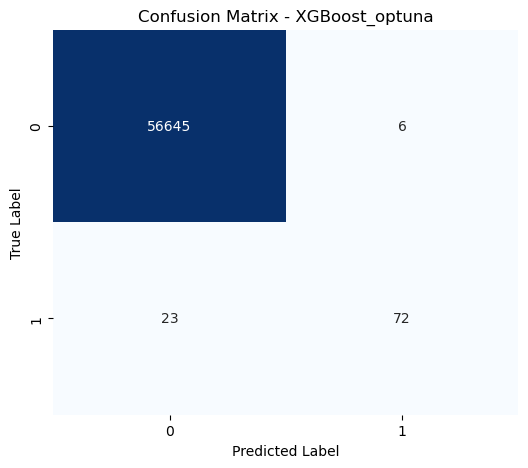

In [6]:
evaluate_model(model_opt[0],x_test,y_test,thershold=0.3,model_name="XGBoost_optuna")

ở đây ta thấy điểm của mô hình ở mức khá tốt rồi nhưng recall so với các mô hình trước vẫn thế để có thể tăng recall lên ta cần tìm ra số thershold tốt nhất.

--- KẾT QUẢ TỐI ƯU (Beta=2) ---
Ngưỡng cắt tốt nhất (Best Threshold): 0.0079
Tại ngưỡng này đạt F2-Score: 0.8212
 -> Precision: 0.7822
 -> Recall:    0.8316


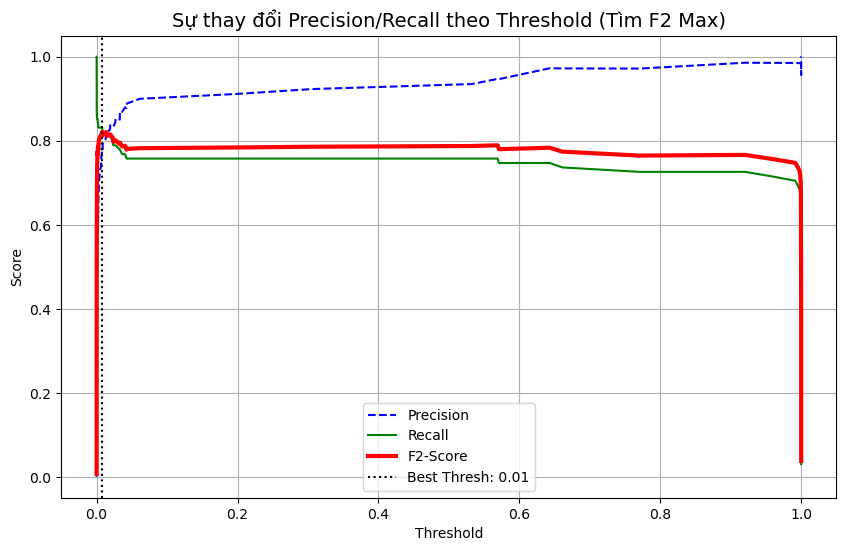

In [9]:
best_thershold = find_optimal_threshold(model_opt[0],x_test,y_test,beta = 2)

--- ĐÁNH GIÁ: XGBOOST_OPTUNA ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.78      0.83      0.81        95

    accuracy                           1.00     56746
   macro avg       0.89      0.92      0.90     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9763
PR-AUC (AUPRC): 0.8272 (Quan trọng cho Fraud)


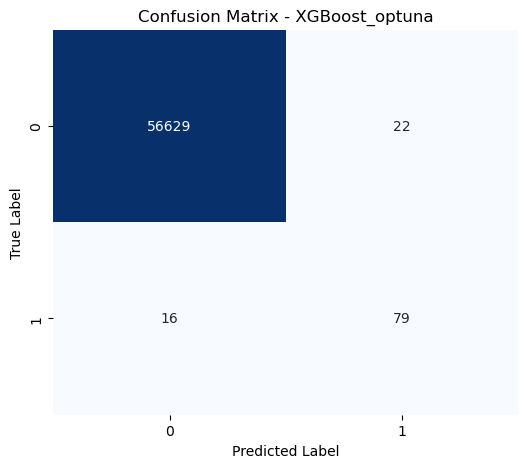

In [10]:
evaluate_model(model_opt[0],x_test,y_test,thershold=best_thershold,model_name="XGBoost_optuna")

với kết quả trên thì mô hình đã có độ chính xác khá cao với bộ dự liệu bị lệch(skew) khá nặng như vậy

Lưu mô hình

In [3]:
otp_path = os.path.join(project_root,'models',"model_xgb_opt_raw.pkl") 


In [4]:
model = joblib.load(otp_path)

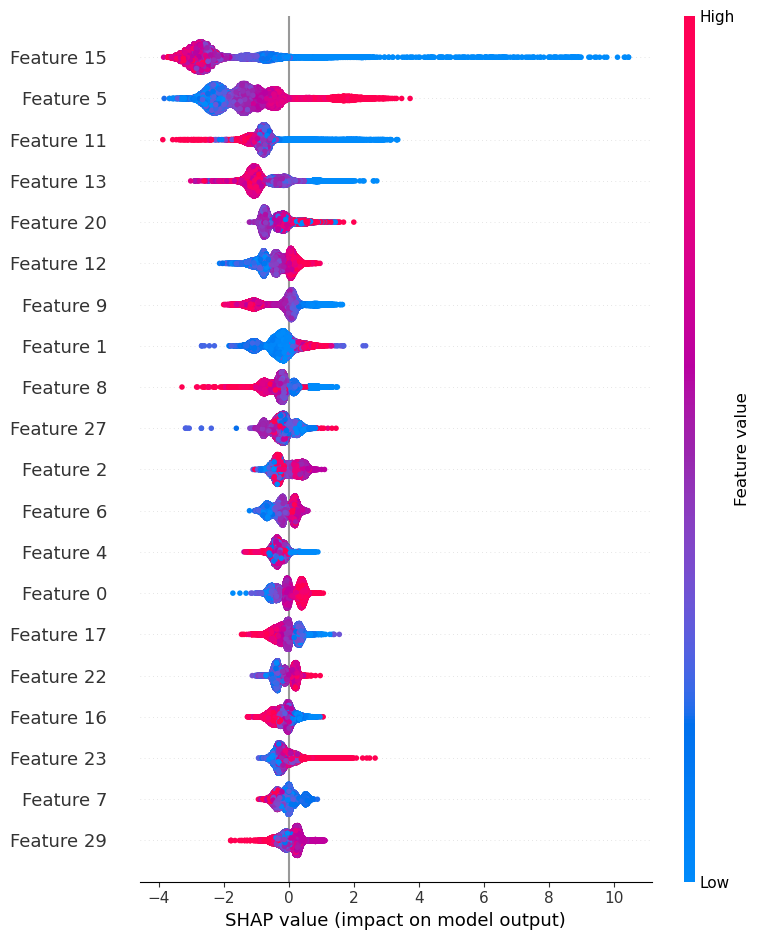

In [7]:
shapBeewarm(model[0],x_test)

In [6]:
plot_force_shap(model[0],x_train,x_test,index = 10)

Đang tạo force plot cho index = 10
Model loại: xgbclassifier
Dùng TreeExplainer...
→ Phát hiện XGBoost style SHAP (2D array)
✔ Force Plot đã hiển thị thành công!
